In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("/content/shopify_stock (1).csv")

In [31]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [32]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

In [33]:
df.dtypes

,0
date,object
open,float64
high,float64
low,float64
close,float64
adj_close,float64
volume,int64


In [34]:
df["date"] = pd.to_datetime(df["date"],utc=True)
df['date'].dtype


datetime64[ns, UTC]

In [35]:
df = df.sort_values("date")

In [36]:
df["Date"] = pd.to_datetime(df["date"],utc=True)
df

,date,open,high,low,close,adj_close,volume,Date
0,2015-05-21 04:00:00+00:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000,2015-05-21 04:00:00+00:00
1,2015-05-22 04:00:00+00:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000,2015-05-22 04:00:00+00:00
2,2015-05-26 04:00:00+00:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000,2015-05-26 04:00:00+00:00
3,2015-05-27 04:00:00+00:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000,2015-05-27 04:00:00+00:00
4,2015-05-28 04:00:00+00:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000,2015-05-28 04:00:00+00:00
...,...,...,...,...,...,...,...,...
2464,2025-03-10 04:00:00+00:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300,2025-03-10 04:00:00+00:00
2465,2025-03-11 04:00:00+00:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100,2025-03-11 04:00:00+00:00
2466,2025-03-12 04:00:00+00:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900,2025-03-12 04:00:00+00:00
2467,2025-03-13 04:00:00+00:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400,2025-03-13 04:00:00+00:00


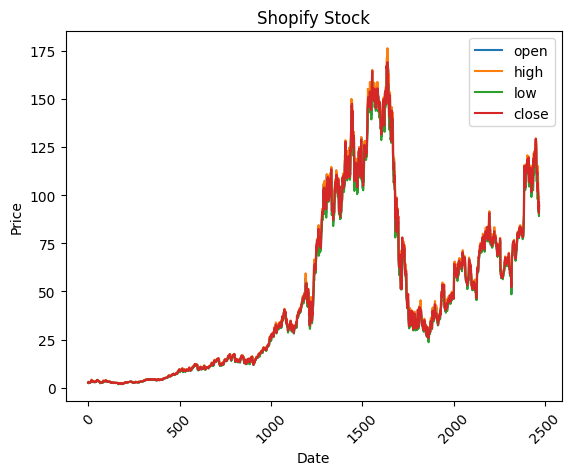

In [37]:


plt.plot(df.index, df["open"], label="open")
plt.plot(df.index, df["high"], label="high")
plt.plot(df.index, df["low"], label="low")
plt.plot(df.index, df["close"], label="close")

plt.title("Shopify Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

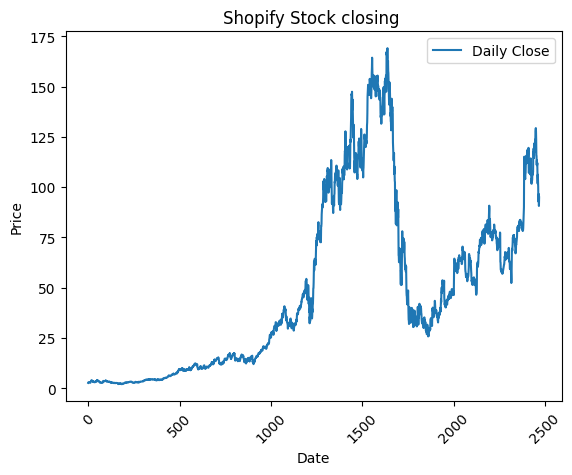

In [38]:
plt.plot(df.index, df["close"], label="Daily Close")
plt.title("Shopify Stock closing ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

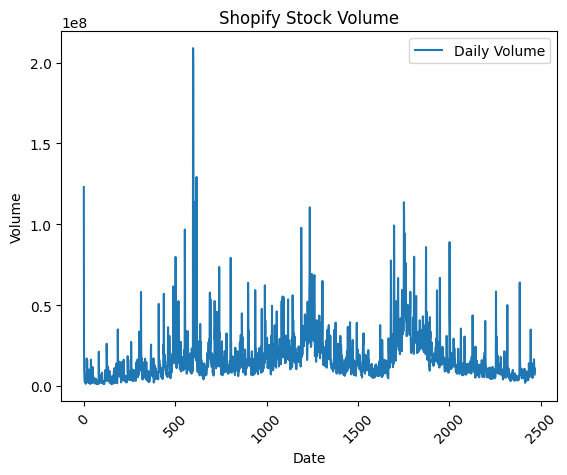

In [39]:
plt.plot(df.index, df["volume"], label="Daily Volume")
plt.title("Shopify Stock Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [40]:

df["MA10"] = df["close"].rolling(window=10).mean()

df["MA50"] = df["close"].rolling(window=50).mean()

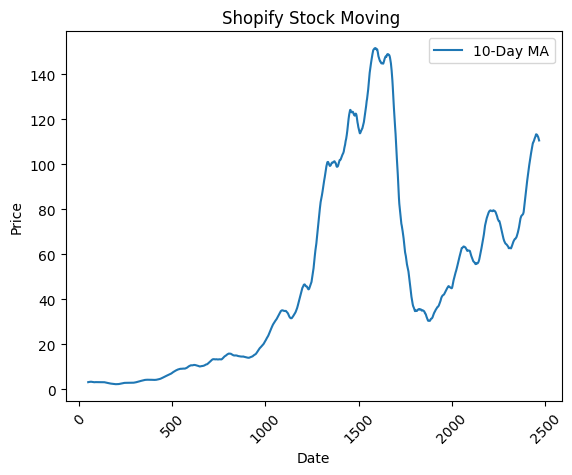

In [41]:
plt.plot(df.index, df["MA50"], label="10-Day MA")

plt.title("Shopify Stock Moving ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

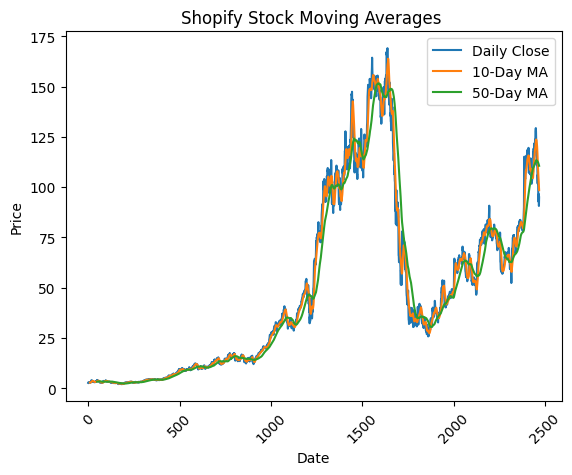

In [42]:
plt.plot(df.index, df["close"], label="Daily Close")
plt.plot(df.index, df["MA10"], label="10-Day MA")
plt.plot(df.index, df["MA50"], label="50-Day MA")
plt.title("Shopify Stock Moving Averages ")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [43]:
df["Daily_Return"]=df["close"].pct_change



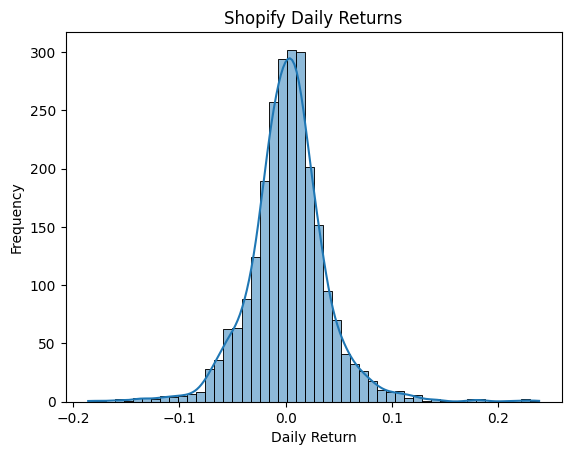

In [45]:
df["Daily_Return"] = df["close"].pct_change()

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Shopify Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [46]:
df["Rolling_Volatility_20"] = (
    df["Daily_Return"]
    .rolling(window=20)
    .std()
)

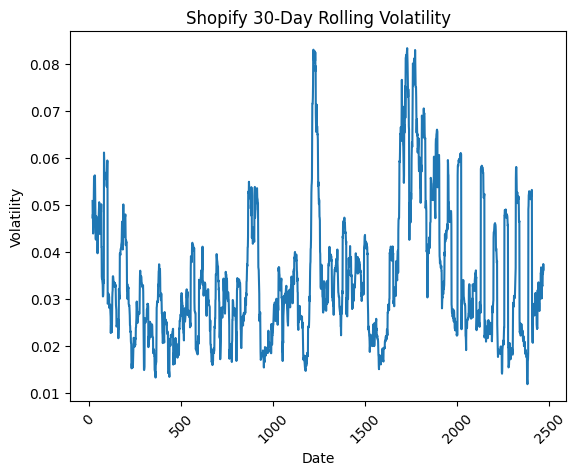

In [49]:
plt.plot(
    df.index,
    df["Rolling_Volatility_20"]
)

plt.title("Shopify 30-Day Rolling ")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.xticks(rotation=45)
plt.show()